<a href="https://colab.research.google.com/github/JorgeLuisMadrid/Aprendizaje-Maquina-2026B/blob/main/L01_03_Perceptron.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# El perceptrón y las compuertas lógicas
## Dr. Carlos Villaseñor

Paso 1. Corre la siguiente casilla para importar la paquetería necesaria.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

Paso 2. Modifica la siguiente clase para que tenga un método de entrenamiento con el algoritmo del perceptrón.

In [2]:
class Perceptron:

  def __init__(self, n_inputs, learning_rate):
    self.w = - 1 + 2 * np.random.rand(n_inputs)
    self.b = - 1 + 2 * np.random.rand()
    self.eta = learning_rate

  def predict(self, X):
    _, p = X.shape
    y_est = np.zeros(p)
    for i in range(p):
      y_est[i] = np.dot(self.w, X[:,i])+self.b
      if y_est[i] >= 0:
        y_est[i]=1
      else:
        y_est[i]=0
    return y_est

  def fit(self, X, Y, epochs=50):
    _, p = X.shape
    for _ in range(epochs):
      for i in range(p):
        # Escribe las ecuaciones del perceptrón
        y_est = self.predict(X[:,i].reshape(-1,1))
        self.w += self.eta*(Y[i]-y_est)*X[:,i]
        self.b += self.eta*(Y[i]-y_est)

Paso 3. Instancía la siguiente función para poder dibujar la línea que representa el Perceptrón.

In [3]:
# Función para dibujar superficie de desición
def draw_2d_percep(model):
  w1, w2, b = model.w[0], model.w[1], model.b
  plt.plot([-2, 2],[(1/w2)*(-w1*(-2)-b),(1/w2)*(-w1*2-b)],'--k')

Paso 4. Corre el siguiente código para comprobar que la neurona es capaz de aprender la compuerta OR

/tmp/ipykernel_1352/29084429.py:12: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  y_est[i] = np.dot(self.w, X[:,i])+self.b


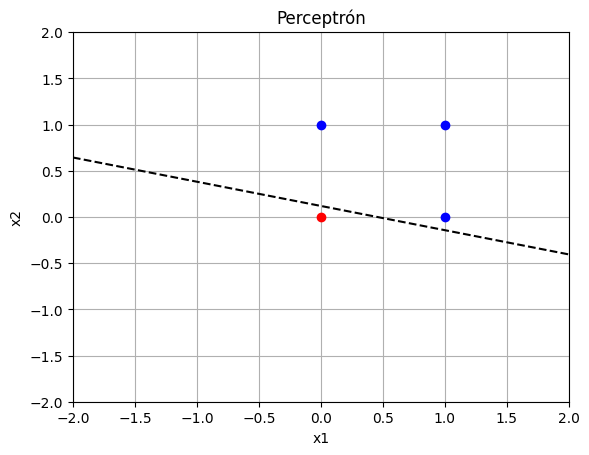

In [5]:
# Instanciar el modelo
model = Perceptron(2, 0.1)

# Datos
X = np.array([[0, 0, 1, 1],
              [0, 1, 0, 1]])
Y = np.array( [0, 1, 1, 1])

# Entrenar
model.fit(X,Y)

# Predicción
model.predict(X)

# Primero dibujemos los puntos
_, p = X.shape
for i in range(p):
  if Y[i] == 0:
    plt.plot(X[0,i],X[1,i], 'or')
  else:
    plt.plot(X[0,i],X[1,i], 'ob')

plt.title('Perceptrón')
plt.grid('on')
plt.xlim([-2,2])
plt.ylim([-2,2])
plt.xlabel(r'x1')
plt.ylabel(r'x2')

draw_2d_percep(model)

Paso 5. Realiza el paso anterior con pero con los datos de la compuerta AND y de la compuerta XOR

/tmp/ipykernel_1352/29084429.py:12: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  y_est[i] = np.dot(self.w, X[:,i])+self.b


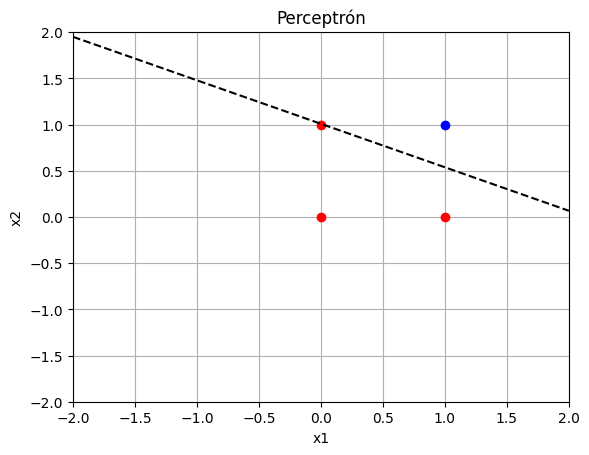

In [6]:
# Datos AND
X = np.array([[0, 0, 1, 1],
              [0, 1, 0, 1]])
Y = np.array( [0, 0, 0, 1])

# Entrenar
model.fit(X,Y)

# Predicción
model.predict(X)

# Primero dibujemos los puntos
_, p = X.shape
for i in range(p):
  if Y[i] == 0:
    plt.plot(X[0,i],X[1,i], 'or')
  else:
    plt.plot(X[0,i],X[1,i], 'ob')

plt.title('Perceptrón')
plt.grid('on')
plt.xlim([-2,2])
plt.ylim([-2,2])
plt.xlabel(r'x1')
plt.ylabel(r'x2')

draw_2d_percep(model)

/tmp/ipykernel_1352/29084429.py:12: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  y_est[i] = np.dot(self.w, X[:,i])+self.b


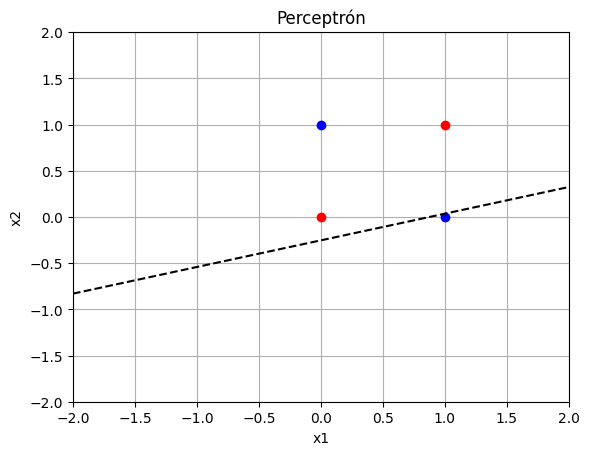

In [7]:
# Datos XOR
X = np.array([[0, 0, 1, 1],
              [0, 1, 0, 1]])
Y = np.array( [0, 1, 1, 0])

# Entrenar
model.fit(X,Y)

# Predicción
model.predict(X)

# Primero dibujemos los puntos
_, p = X.shape
for i in range(p):
  if Y[i] == 0:
    plt.plot(X[0,i],X[1,i], 'or')
  else:
    plt.plot(X[0,i],X[1,i], 'ob')

plt.title('Perceptrón')
plt.grid('on')
plt.xlim([-2,2])
plt.ylim([-2,2])
plt.xlabel(r'x1')
plt.ylabel(r'x2')

draw_2d_percep(model)

Paso 6. ¿Que diferencia puedes notar entre el aprendizaje de la compuerta AND y la compuerta XOR?: Escribe aquí tu respuesta

El perceptrón puede aprender fácilmente la compuerta AND porque es **linealmente separable**. Esto significa que se puede trazar una sola línea recta para separar los puntos de datos de salida 0 de los puntos de datos de salida 1.

Sin embargo, el perceptrón **no puede aprender la compuerta XOR** porque no es linealmente separable. No hay una sola línea recta que pueda separar los puntos de datos de salida 0 (0,0 y 1,1) de los puntos de datos de salida 1 (0,1 y 1,0). El perceptrón es un clasificador lineal y la función XOR requiere una separación no lineal.

Respuesta: